
 LOGISTIC REGRESSION RESULTS 
Accuracy: 0.6725

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.70      0.75      1439
           1       0.44      0.60      0.51       561

    accuracy                           0.67      2000
   macro avg       0.63      0.65      0.63      2000
weighted avg       0.71      0.67      0.69      2000



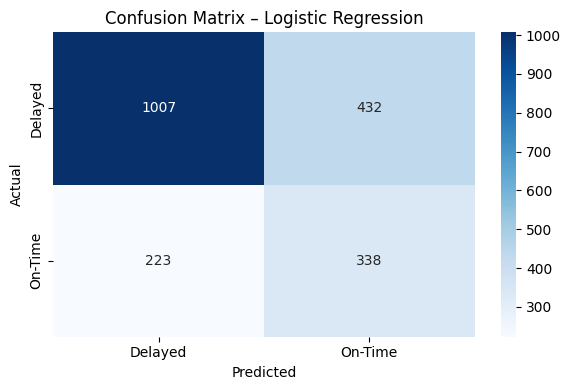

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

# =========================
# LOAD CLEAN DATA
# =========================

df = pd.read_csv(
    "C:\\Users\\Shreyas\\Desktop\\shipment sure project\\Data\\processed\\shipment_dataset_with_weekend_features.csv"
)

# Target
y = df["on_time_delivery"]

# Drop leakage & IDs
X = df.drop(columns=["on_time_delivery", "total_order_value", "supplier_id", "order_id"], errors="ignore")

# =========================
# FEATURE GROUPS
# =========================

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# =========================
# PREPROCESSING PIPELINE
# =========================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(
        degree=2,
        interaction_only=True,
        include_bias=False
    ))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

# =========================
# LOGISTIC REGRESSION
# =========================

logistic = LogisticRegression(
    C=2.0,
    solver="lbfgs",
    max_iter=600,
    class_weight="balanced",
    n_jobs=-1
)

# Full pipeline
model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", logistic)
])

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# TRAIN
# =========================

model.fit(X_train, y_train)

# =========================
# EVALUATION
# =========================

y_pred = model.predict(X_test)

print("\n==============================")
print(" LOGISTIC REGRESSION RESULTS ")
print("==============================")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Delayed", "On-Time"],
    yticklabels=["Delayed", "On-Time"]
)
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



 RANDOM FOREST RESULTS 
Accuracy: 0.798

Classification Report:
               precision    recall  f1-score   support

           0       0.78      1.00      0.88      1439
           1       0.98      0.29      0.44       561

    accuracy                           0.80      2000
   macro avg       0.88      0.64      0.66      2000
weighted avg       0.84      0.80      0.76      2000



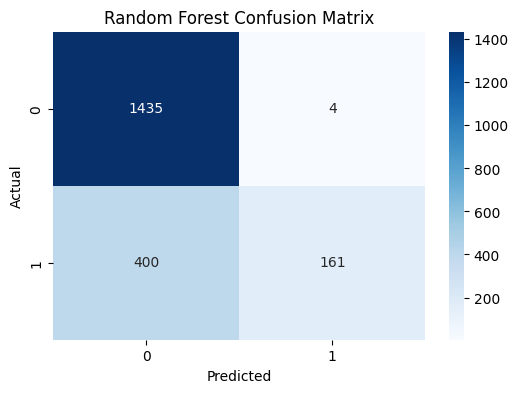

In [2]:
# ================================
# RANDOM FOREST – FINAL PIPELINE
# ================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ================================
# 1. LOAD CLEANED DATASET
# ================================
df = pd.read_csv(
    "C:\\Users\\Shreyas\\Desktop\\shipment sure project\\Data\\processed\\shipment_dataset_with_weekend_features.csv"
)

# ================================
# 2. FEATURE ENGINEERING
# ================================
# Log transform improves tree splits
df['log_order_value'] = np.log1p(df['total_order_value'])

# Target
y = df['on_time_delivery']

# Drop IDs + leakage columns
X = df.drop(
    columns=[
        'on_time_delivery',
        'total_order_value',
        'supplier_id',
        'order_id'
    ],
    errors='ignore'
)

# ================================
# 3. ENCODE CATEGORICAL FEATURES
# ================================
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# ================================
# 4. HANDLE ANY REMAINING NaN (CRITICAL)
# ================================
X = X.fillna(X.median())

# ================================
# 5. TRAIN–TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# 6. RANDOM FOREST MODEL (TUNED)
# ================================
rf_model = RandomForestClassifier(
    n_estimators=600,
    max_depth=22,
    min_samples_split=6,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight={0: 1, 1: 2},  # boost minority class
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# ================================
# 7. PREDICTION & EVALUATION
# ================================
rf_pred = rf_model.predict(X_test)

print("\n==============================")
print(" RANDOM FOREST RESULTS ")
print("==============================")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

# ================================
# 8. CONFUSION MATRIX
# ================================
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



 XGBOOST RESULTS 
Best Threshold: 0.47
Accuracy: 0.8625

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91      1439
           1       0.77      0.73      0.75       561

    accuracy                           0.86      2000
   macro avg       0.83      0.82      0.83      2000
weighted avg       0.86      0.86      0.86      2000



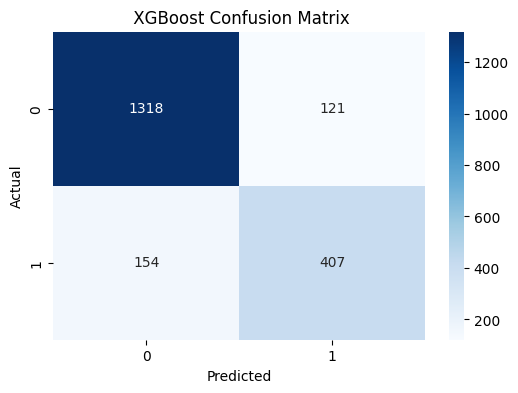

Model saved as xgboost_shipment_model.pkl


In [2]:
# =========================================
# ULTRA-BOOSTED XGBOOST (MAX ACCURACY)
# =========================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================
# 1. LOAD CLEAN DATA
# =========================================
df = pd.read_csv(
    "C:\\Users\\Shreyas\\Desktop\\shipment sure project\\Data\\processed\\shipment_dataset_with_weekend_features.csv"
)

# =========================================
# 2. ADVANCED FEATURE ENGINEERING
# =========================================
df['log_order_value'] = np.log1p(df['total_order_value'])

df['order_per_lead'] = df['log_order_value'] / (df['supplier_lead_time'] + 1)
df['lead_x_order'] = df['supplier_lead_time'] * df['log_order_value']
df['lead_squared'] = df['supplier_lead_time'] ** 2

# Target
y = df['on_time_delivery']

# Drop leakage + IDs
X = df.drop(
    columns=[
        'on_time_delivery',
        'total_order_value',
        'supplier_id',
        'order_id'
    ],
    errors='ignore'
)

# =========================================
# 3. LABEL ENCODING
# =========================================
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# =========================================
# 4. HANDLE NaNs (IMPORTANT)
# =========================================
X = X.fillna(X.median())

# =========================================
# 5. TRAIN-TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================
# 6. CLASS IMBALANCE WEIGHT
# =========================================
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

# =========================================
# 7. ULTRA-TUNED XGBOOST
# =========================================
xgb_model = XGBClassifier(
    n_estimators=900,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.2,
    reg_alpha=0.3,
    reg_lambda=1.2,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# =========================================
# 8. TRAIN
# =========================================
xgb_model.fit(X_train, y_train)

# =========================================
# 9. AUTO THRESHOLD SEARCH (KEY BOOST)
# =========================================
probs = xgb_model.predict_proba(X_test)[:, 1]

best_acc = 0
best_thresh = 0.5

for t in np.arange(0.30, 0.70, 0.01):
    preds = (probs >= t).astype(int)
    acc = accuracy_score(y_test, preds)
    if acc > best_acc:
        best_acc = acc
        best_thresh = t

xgb_pred = (probs >= best_thresh).astype(int)

# =========================================
# 10. RESULTS
# =========================================
print("\n==============================")
print(" XGBOOST RESULTS ")
print("==============================")
print(f"Best Threshold: {best_thresh:.2f}")
print(f"Accuracy: {best_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, xgb_pred))

# =========================================
# 11. CONFUSION MATRIX
# =========================================
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt="d", cmap="Blues")
plt.title(" XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


import joblib

joblib.dump(xgb_model, "xgboost_shipment_model.pkl")
print("Model saved as xgboost_shipment_model.pkl")
